# Final Guided KeyBERT Notebook

Guided Keyphrase Extraction for Stakeholder Value Identification in Transportation Resilience Literature.

Pipeline:
1. Data generation
2. Preprocessing
3. KeyBERT modeling
4. Category mapping
5. Evaluation setup
6. Visualization
7. Robustness checks


In [1]:
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (9, 5)

CURRENT = Path.cwd()

if CURRENT.name.lower() == "notebooks":
    PROJECT_ROOT = CURRENT.parent
else:
    PROJECT_ROOT = CURRENT

# Flexible folder names for Windows/GitHub compatibility
data_folder = PROJECT_ROOT / "data"
if not data_folder.exists():
    data_folder = PROJECT_ROOT / "Data"

outputs_folder = PROJECT_ROOT / "outputs"
if not outputs_folder.exists():
    outputs_folder = PROJECT_ROOT / "Outputs"

DATA_PATH = data_folder / "raw" / "papers_metadata.csv"
if not DATA_PATH.exists():
    DATA_PATH = data_folder / "Raw" / "papers_metadata.csv"

OUTPUT_TABLES = outputs_folder / "tables"
if not OUTPUT_TABLES.exists():
    OUTPUT_TABLES = outputs_folder / "Tables"

OUTPUT_FIGURES = outputs_folder / "figures"
if not OUTPUT_FIGURES.exists():
    OUTPUT_FIGURES = outputs_folder / "Figures"

OUTPUT_TABLES.mkdir(parents=True, exist_ok=True)
OUTPUT_FIGURES.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data path:", DATA_PATH)
print("CSV exists:", DATA_PATH.exists())
print("Output tables:", OUTPUT_TABLES)
print("Output figures:", OUTPUT_FIGURES)

Project root: d:\UTA Study Materials\Coursework\4. Spring 2026\ML\Project\Project\OneDrive_2026-04-20\New Project\keybert-stakeholder-values\keybert-stakeholder-values
Data path: d:\UTA Study Materials\Coursework\4. Spring 2026\ML\Project\Project\OneDrive_2026-04-20\New Project\keybert-stakeholder-values\keybert-stakeholder-values\data\raw\papers_metadata.csv
CSV exists: True
Output tables: d:\UTA Study Materials\Coursework\4. Spring 2026\ML\Project\Project\OneDrive_2026-04-20\New Project\keybert-stakeholder-values\keybert-stakeholder-values\outputs\tables
Output figures: d:\UTA Study Materials\Coursework\4. Spring 2026\ML\Project\Project\OneDrive_2026-04-20\New Project\keybert-stakeholder-values\keybert-stakeholder-values\outputs\figures


In [2]:
df = pd.read_csv(DATA_PATH, encoding="cp1252")

if "text" in df.columns and "full_text" not in df.columns:
    df = df.rename(columns={"text": "full_text"})

required_cols = ["paper_id", "title", "full_text"]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

if "keywords" not in df.columns:
    df["keywords"] = ""

for col in ["title", "full_text", "keywords"]:
    df[col] = df[col].fillna("").astype(str)

df["combined_text"] = df["title"] + " " + df["keywords"] + " " + df["full_text"]

print(df.shape)
print(df.columns.tolist())
df.head()


(20, 5)
['paper_id', 'title', 'full_text', 'keywords', 'combined_text']


,paper_id,title,full_text,keywords,combined_text
0,1,Transportation system performance capabilities...,1. Introduction \nTransportation systems have ...,Resilience; Transportation systems; resilience...,Transportation system performance capabilities...
1,2,Achieving Postdisaster Reconstruction Success ...,Introduction\nThe increasing rate of natural d...,Contractors’ services; Client values; Postdisa...,Achieving Postdisaster Reconstruction Success ...
2,3,Developing Resilience in\nDisaster Relief Oper...,Highlights \n\no This research aims to investi...,Operations management; Lean transformation; Va...,Developing Resilience in\nDisaster Relief Oper...
3,4,The underestimated role of the transportation ...,\n1.Introduction \n\n\nThe transportation netw...,Resilience; Transport networks; Equity; Access...,The underestimated role of the transportation ...
4,5,Transportation Resilience under Climate Change...,\n\n\n\n \n\nINTRODUCTION \n\nResilience in tr...,"Transportation Resilience, Natural Disasters, ...",Transportation Resilience under Climate Change...


In [3]:
def clean_text(text: str) -> str:
    text = str(text)
    text = text.replace("\n", " ").replace("\r", " ").replace("\t", " ")
    text = text.replace("", "'").replace("’", "'").replace("“", '"').replace("”", '"')
    text = text.replace("\x02", " ").replace("\xa0", " ")
    text = text.lower()

    text = re.sub(r"http\S+|www\S+", " ", text)

    # citation and publication noise
    for pattern in [r"\bet al\b", r"\bet\b", r"\bal\b", r"\bdoi\b", r"\barxiv\b"]:
        text = re.sub(pattern, " ", text)

    publisher_terms = [
        "elsevier", "springer", "wiley", "emerald", "taylor francis",
        "american society of civil engineers", "asce", "crc press"
    ]
    for term in publisher_terms:
        text = re.sub(rf"\b{re.escape(term)}\b", " ", text)

    # figure/table/page references
    text = re.sub(r"\bfigure\s*\d+\b", " ", text)
    text = re.sub(r"\bfig\s*\d+\b", " ", text)
    text = re.sub(r"\btable\s*\d+\b", " ", text)
    text = re.sub(r"\bpage\s*\d+\b", " ", text)

    # references section
    text = re.sub(r"\breferences\b.*$", " ", text, flags=re.IGNORECASE | re.DOTALL)

    text = re.sub(r"[^a-zA-Z0-9\s\-]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["combined_text"].apply(clean_text)
print(df["clean_text"].iloc[0][:700])


transportation system performance capabilities for vulnerable populations resilience transportation systems resilience equity social justice asset management organizational resilience vulnerable populations mobility vulnerability 1 introduction transportation systems have a critical role in the functioning of societies as they facilitate the mobility of users and freight the provision of essential services and the achievement of economic prosperity 1 however these systems are under continuous pressure to perform with the increasing intensities and frequencies of natural and technical risks the stress on the capital required tomanage the infrastructure after the occurrence of a disruptive eve


## Install packages if needed

Uncomment and run the next line if KeyBERT is not installed.


In [4]:
# !pip install keybert sentence-transformers scikit-learn


In [5]:
from keybert import KeyBERT

kw_model = KeyBERT(model="all-MiniLM-L6-v2")
print("KeyBERT model loaded.")


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

KeyBERT model loaded.


In [6]:
value_framework = {
    "Flexibility": ["flexibility", "flexible", "adaptive capacity", "flexible recovery", "flexible planning"],
    "Safety": ["safety", "public safety", "traffic safety", "emergency safety", "hazard reduction", "risk reduction", "evacuation safety"],
    "Recoverability": ["recoverability", "recovery", "service recovery", "system recovery", "post-disaster recovery"],
    "Reliability": ["reliability", "reliable", "system reliability", "service reliability", "continuity", "service continuity", "operational continuity"],
    "Functionality": ["functionality", "functional performance", "system function", "network function", "service function", "operational function"],
    "Redundancy": ["redundancy", "redundant", "alternative route", "backup system", "system redundancy", "network redundancy", "substitution"],
    "Connectivity": ["connectivity", "network connectivity", "road connectivity", "regional connectivity", "transport connectivity"],
    "Restoration Speed": ["restoration speed", "rapid restoration", "rapid repair", "repair speed", "quick recovery", "rapid response", "response time", "restoration time"],
    "Economic Recovery": ["economic recovery", "business recovery", "regional recovery", "economic restoration", "local economy", "economic activity"],
    "Robustness": ["robustness", "robust", "system robustness", "structural robustness", "network robustness", "hazard resistance"],
    "Operational Performance": ["operational performance", "operation", "operations", "traffic operation", "system performance", "network performance", "travel performance"],
    "Capacity": ["capacity", "system capacity", "road capacity", "traffic capacity", "network capacity", "service capacity"],
    "Accessibility": ["accessibility", "access", "accessible", "road access", "public access", "transportation access", "service access", "transit access"],
    "Mobility": ["mobility", "travel mobility", "transport mobility", "movement", "travel time", "traffic flow", "evacuation mobility"],
    "Equity": ["equity", "equitable", "fairness", "justice", "social equity", "vulnerable populations", "underserved communities", "inclusion", "social vulnerability"],
    "Public Health Support": ["public health", "health support", "healthcare access", "medical access", "emergency medical", "health service", "hospital access"],
    "Economic Continuity": ["economic continuity", "business continuity", "economic resilience", "supply chain continuity", "financial continuity"],
    "Cost-effectiveness": ["cost-effectiveness", "cost effectiveness", "cost efficient", "cost efficiency", "low cost", "life cycle cost", "recovery cost", "investment efficiency"],
    "Resource Availability": ["resource availability", "available resources", "funding availability", "recovery resources", "emergency resources", "material availability", "staff availability"],
    "Environmental Protection": ["environmental protection", "environmental impact", "ecosystem protection", "ecological protection", "natural resource protection", "habitat protection"],
    "Sustainability": ["sustainability", "sustainable", "long-term sustainability", "sustainable recovery", "climate resilience", "climate adaptation"],
    "Pollution Prevention": ["pollution prevention", "pollution control", "air pollution", "emission reduction", "environmental pollution", "contamination prevention"],
    "Resilience": ["resilience", "resilient", "transportation resilience", "infrastructure resilience", "community resilience", "disaster resilience"],
    "Responsiveness": ["responsiveness", "responsive", "response", "emergency response", "rapid response", "response capability", "response time"],
    "Adaptability": ["adaptability", "adaptable", "adaptation", "adaptive", "adaptive planning", "climate adaptation", "adaptive capacity"],
    "Serviceability": ["serviceability", "serviceable", "service performance", "service restoration", "service availability", "transport service", "level of service"]
}

print("Number of value categories:", len(value_framework))


Number of value categories: 26


In [7]:
TOP_N = 20

all_doc_keywords = []

for _, row in df.iterrows():
    keywords = kw_model.extract_keywords(
        row["clean_text"],
        keyphrase_ngram_range=(1, 3),
        stop_words="english",
        top_n=TOP_N,
        use_mmr=True,
        diversity=0.7
    )

    for phrase, score in keywords:
        all_doc_keywords.append({
            "paper_id": row["paper_id"],
            "title": row["title"],
            "phrase": phrase,
            "score": score
        })

keywords_df = pd.DataFrame(all_doc_keywords)
print("Extracted phrase rows:", keywords_df.shape[0])
keywords_df.head(20)


Extracted phrase rows: 400


,paper_id,title,phrase,score
0,1,Transportation system performance capabilities...,resilience transportation relatesto,0.8324
1,1,Transportation system performance capabilities...,organization unable anticipate,0.2182
2,1,Transportation system performance capabilities...,concerns users experts,0.2075
3,1,Transportation system performance capabilities...,college degree vulnerable,0.2005
4,1,Transportation system performance capabilities...,critical define,0.1763
5,1,Transportation system performance capabilities...,evolutionary paradigm engineering,0.1740
6,1,Transportation system performance capabilities...,area flood zones,0.1354
7,1,Transportation system performance capabilities...,characteristics define,0.1309
8,1,Transportation system performance capabilities...,complexities identities,0.1176
9,1,Transportation system performance capabilities...,agencies 58 33,0.0893


In [8]:
phrase_summary = (
    keywords_df.groupby("phrase")
    .agg(
        doc_count=("paper_id", "nunique"),
        occurrence_count=("paper_id", "count"),
        mean_score=("score", "mean"),
        total_score=("score", "sum")
    )
    .reset_index()
    .sort_values(["doc_count", "mean_score", "total_score"], ascending=False)
)

phrase_summary.head(30)


,phrase,doc_count,occurrence_count,mean_score,total_score
310,resilience transportation relatesto,1,1,0.8324,0.8324
133,disaster resilience infrastructure,1,1,0.7643,0.7643
207,infrastructure climate change,1,1,0.7503,0.7503
132,disaster reconstruction projects,1,1,0.7420,0.7420
144,earthquake resilient lifelines,1,1,0.7387,0.7387
134,disaster resilience transportation,1,1,0.7361,0.7361
41,analyze resilience transportation,1,1,0.7344,0.7344
308,resilience road asset,1,1,0.7331,0.7331
39,ai crisis management,1,1,0.7234,0.7234
311,resilience transportation systems,1,1,0.7160,0.7160


In [9]:
def map_phrase_to_categories(phrase, framework):
    phrase_l = phrase.lower()
    matched = []

    for category, refs in framework.items():
        for ref in refs:
            ref_l = ref.lower()
            if ref_l in phrase_l or phrase_l in ref_l:
                matched.append(category)
                break

    return matched if matched else ["Emerging/Unmapped"]

mapped_rows = []

for _, row in phrase_summary.iterrows():
    cats = map_phrase_to_categories(row["phrase"], value_framework)
    for cat in cats:
        mapped_rows.append({
            "phrase": row["phrase"],
            "category": cat,
            "doc_count": row["doc_count"],
            "occurrence_count": row["occurrence_count"],
            "mean_score": row["mean_score"],
            "total_score": row["total_score"]
        })

mapped_df = pd.DataFrame(mapped_rows)
mapped_df.head(20)


,phrase,category,doc_count,occurrence_count,mean_score,total_score
0,resilience transportation relatesto,Resilience,1,1,0.8324,0.8324
1,disaster resilience infrastructure,Resilience,1,1,0.7643,0.7643
2,infrastructure climate change,Emerging/Unmapped,1,1,0.7503,0.7503
3,disaster reconstruction projects,Emerging/Unmapped,1,1,0.7420,0.7420
4,earthquake resilient lifelines,Resilience,1,1,0.7387,0.7387
5,disaster resilience transportation,Resilience,1,1,0.7361,0.7361
6,analyze resilience transportation,Resilience,1,1,0.7344,0.7344
7,resilience road asset,Resilience,1,1,0.7331,0.7331
8,ai crisis management,Emerging/Unmapped,1,1,0.7234,0.7234
9,resilience transportation systems,Resilience,1,1,0.7160,0.7160


In [10]:
category_summary = (
    mapped_df.groupby("category")
    .agg(
        unique_phrases=("phrase", "nunique"),
        total_doc_support=("doc_count", "sum"),
        avg_phrase_score=("mean_score", "mean")
    )
    .reset_index()
    .sort_values(["total_doc_support", "unique_phrases"], ascending=False)
)

category_summary


,category,unique_phrases,total_doc_support,avg_phrase_score
3,Emerging/Unmapped,363,363,0.142676
8,Resilience,14,14,0.709493
6,Recoverability,7,7,0.168314
1,Adaptability,3,3,0.233533
11,Safety,3,3,0.245533
5,Operational Performance,2,2,0.324000
7,Reliability,2,2,0.300000
9,Responsiveness,2,2,0.091050
10,Robustness,2,2,0.124150
0,Accessibility,1,1,0.163700


In [11]:
example_rows = []

for category in category_summary["category"]:
    cat_phrases = mapped_df[mapped_df["category"] == category].copy()
    cat_phrases = cat_phrases.sort_values(
        ["doc_count", "mean_score", "total_score"],
        ascending=False
    ).drop_duplicates(subset=["phrase"]).head(5)

    example_rows.append({
        "category": category,
        "example_phrases": "; ".join(cat_phrases["phrase"].tolist())
    })

examples_df = pd.DataFrame(example_rows)
examples_df


,category,example_phrases
0,Emerging/Unmapped,infrastructure climate change; disaster recons...
1,Resilience,resilience transportation relatesto; disaster ...
2,Recoverability,recovery controller; recovery paths specified;...
3,Adaptability,adaptation mitigating emissions; development a...
4,Safety,centricagenciestobecomingmultimodalagencieswit...
5,Operational Performance,disaster resilient operations; operations oper...
6,Reliability,40 higher reliability; reliability restoration...
7,Responsiveness,increase response; response minimizing likelihood
8,Robustness,robustness safety privacy; robust view range
9,Accessibility,communities lack access


## Precision@10 review table

Open the generated CSV and fill `relevant_manual_review` with:
- `1` if the phrase is relevant to the category
- `0` if it is not relevant

Then run the precision calculation cell.


In [12]:
K = 10

review_rows = []

for category in category_summary["category"]:
    cat_phrases = mapped_df[mapped_df["category"] == category].copy()
    cat_phrases = cat_phrases.sort_values(
        ["doc_count", "mean_score", "total_score"],
        ascending=False
    ).drop_duplicates(subset=["phrase"]).head(K)

    for _, row in cat_phrases.iterrows():
        review_rows.append({
            "category": category,
            "phrase": row["phrase"],
            "doc_count": row["doc_count"],
            "mean_score": row["mean_score"],
            "relevant_manual_review": ""
        })

review_df = pd.DataFrame(review_rows)

blank_review_path = OUTPUT_TABLES / "keyphrase_review_table_blank.csv"
review_df.to_csv(blank_review_path, index=False)

print("Blank review table saved to:", blank_review_path)
review_df.head(30)

Blank review table saved to: d:\UTA Study Materials\Coursework\4. Spring 2026\ML\Project\Project\OneDrive_2026-04-20\New Project\keybert-stakeholder-values\keybert-stakeholder-values\outputs\tables\keyphrase_review_table_blank.csv


,category,phrase,doc_count,mean_score,relevant_manual_review
0,Emerging/Unmapped,infrastructure climate change,1,0.7503,
1,Emerging/Unmapped,disaster reconstruction projects,1,0.7420,
2,Emerging/Unmapped,ai crisis management,1,0.7234,
3,Emerging/Unmapped,disaster impacts,1,0.7054,
4,Emerging/Unmapped,disasters stakeholder,1,0.6942,
5,Emerging/Unmapped,state disaster impact,1,0.6366,
6,Emerging/Unmapped,impacts climate extreme,1,0.4486,
7,Emerging/Unmapped,58 pavement performance,1,0.4181,
8,Emerging/Unmapped,road assets underwent,1,0.4038,
9,Emerging/Unmapped,indonesia event,1,0.3841,


In [13]:
filled_review_path = OUTPUT_TABLES / "keyphrase_review_table_filled.csv"

if filled_review_path.exists():
    reviewed = pd.read_csv(filled_review_path)

    reviewed["relevant_manual_review"] = pd.to_numeric(
        reviewed["relevant_manual_review"],
        errors="coerce"
    ).fillna(0)

    precision_df = (
        reviewed.groupby("category")["relevant_manual_review"]
        .mean()
        .reset_index()
        .rename(columns={"relevant_manual_review": "precision_at_10"})
    )

    precision_df["precision_at_10_percent"] = precision_df["precision_at_10"] * 100

    precision_df = precision_df.sort_values("precision_at_10", ascending=False)

    precision_output_path = OUTPUT_TABLES / "precision_at_10_by_category.csv"
    precision_df.to_csv(precision_output_path, index=False)

    print("Precision@10 saved to:", precision_output_path)
    display(precision_df)
else:
    print("Filled manual review file not found.")
    print("Expected file:", filled_review_path)
    print("The extraction pipeline still runs, but Precision@10 requires the completed manual review CSV.")


Precision@10 saved to: d:\UTA Study Materials\Coursework\4. Spring 2026\ML\Project\Project\OneDrive_2026-04-20\New Project\keybert-stakeholder-values\keybert-stakeholder-values\outputs\tables\precision_at_10_by_category.csv


,category,precision_at_10,precision_at_10_percent
26,Sustainability,1.000000,100.000000
10,Flexibility,1.000000,100.000000
21,Responsiveness,1.000000,100.000000
18,Reliability,1.000000,100.000000
4,Cost-effectiveness,1.000000,100.000000
6,Economic Recovery,1.000000,100.000000
1,Adaptability,1.000000,100.000000
8,Environmental Protection,1.000000,100.000000
12,Mobility,1.000000,100.000000
16,Recoverability,0.900000,90.000000


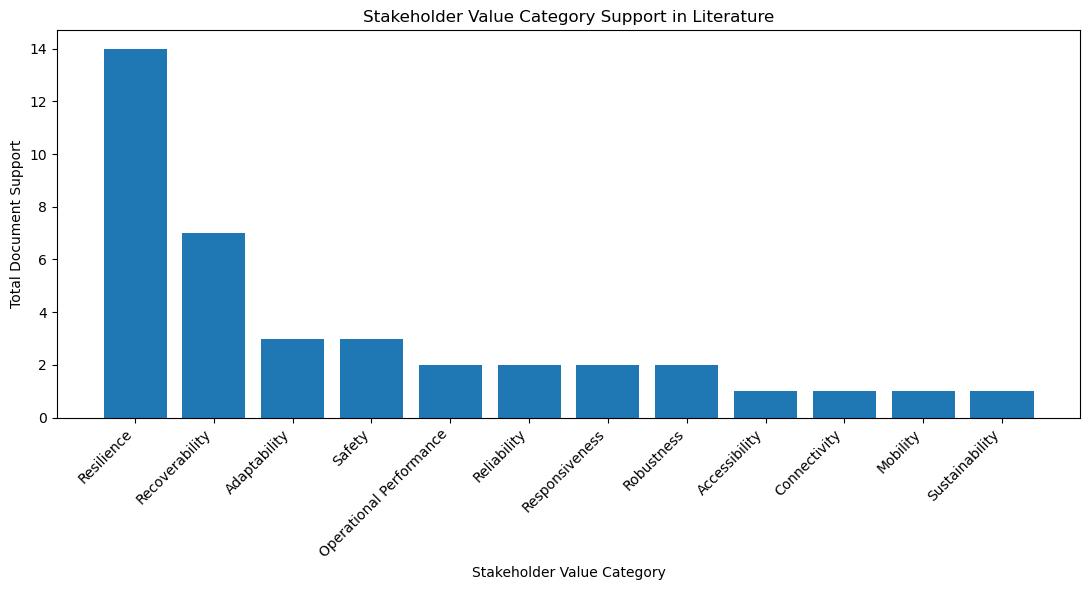

In [14]:
plot_df = category_summary[category_summary["category"] != "Emerging/Unmapped"].copy()
plot_df = plot_df.sort_values("total_doc_support", ascending=False).head(15)

plt.figure(figsize=(11, 6))
plt.bar(plot_df["category"], plot_df["total_doc_support"])
plt.xticks(rotation=45, ha="right")
plt.title("Stakeholder Value Category Support in Literature")
plt.xlabel("Stakeholder Value Category")
plt.ylabel("Total Document Support")
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES / "stakeholder_value_category_support.png", dpi=300)
plt.show()


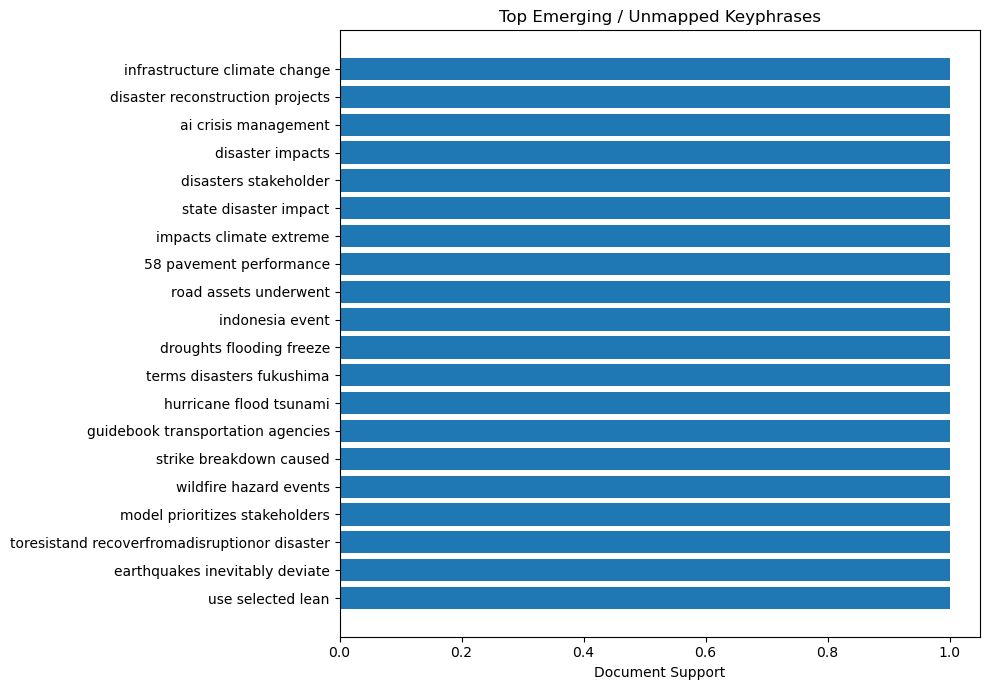

,phrase,doc_count,mean_score
2,infrastructure climate change,1,0.7503
3,disaster reconstruction projects,1,0.7420
8,ai crisis management,1,0.7234
11,disaster impacts,1,0.7054
14,disasters stakeholder,1,0.6942
18,state disaster impact,1,0.6366
21,impacts climate extreme,1,0.4486
22,58 pavement performance,1,0.4181
23,road assets underwent,1,0.4038
24,indonesia event,1,0.3841


In [15]:
emerging_df = mapped_df[mapped_df["category"] == "Emerging/Unmapped"].copy()
emerging_df = emerging_df.sort_values(
    ["doc_count", "mean_score", "total_score"],
    ascending=False
).drop_duplicates(subset=["phrase"])

emerging_top = emerging_df.head(20)

if len(emerging_top) > 0:
    plt.figure(figsize=(10, 7))
    plt.barh(emerging_top["phrase"][::-1], emerging_top["doc_count"][::-1])
    plt.title("Top Emerging / Unmapped Keyphrases")
    plt.xlabel("Document Support")
    plt.tight_layout()
    plt.savefig(OUTPUT_FIGURES / "emerging_unmapped_keyphrases.png", dpi=300)
    plt.show()

emerging_top[["phrase", "doc_count", "mean_score"]]


## Robustness checks

This section compares:
1. Top 10 vs top 20 phrase extraction
2. Metadata-only extraction using title + keywords


In [17]:
def extract_keybert_phrases(dataframe, text_col, top_n=10, ngram_range=(1, 3), diversity=0.7):
    rows = []
    for _, row in dataframe.iterrows():
        keywords = kw_model.extract_keywords(
            row[text_col],
            keyphrase_ngram_range=ngram_range,
            stop_words="english",
            top_n=top_n,
            use_mmr=True,
            diversity=diversity
        )
        for phrase, score in keywords:
            rows.append({
                "paper_id": row["paper_id"],
                "phrase": phrase,
                "score": score
            })
    return pd.DataFrame(rows)

keywords_top10 = extract_keybert_phrases(df, "clean_text", top_n=10)
df["metadata_text"] = (df["title"] + " " + df["keywords"]).apply(clean_text)
metadata_keywords = extract_keybert_phrases(df, "metadata_text", top_n=10)

print("Top10 extraction rows:", keywords_top10.shape)
print("Metadata-only extraction rows:", metadata_keywords.shape)
metadata_keywords.head()


Top10 extraction rows: (200, 3)
Metadata-only extraction rows: (200, 3)


,paper_id,phrase,score
0,1,transportation systems resilience,0.7855
1,1,vulnerable populations resilience,0.6107
2,1,transportation performance capabilities,0.5752
3,1,mobility,0.4050
4,1,performance capabilities vulnerable,0.3745


In [18]:
keywords_df.to_csv(OUTPUT_TABLES / "all_keybert_keywords.csv", index=False)
phrase_summary.to_csv(OUTPUT_TABLES / "keyphrase_corpus_summary.csv", index=False)
mapped_df.to_csv(OUTPUT_TABLES / "keyphrase_mapped_value_categories.csv", index=False)
category_summary.to_csv(OUTPUT_TABLES / "stakeholder_value_category_summary.csv", index=False)
examples_df.to_csv(OUTPUT_TABLES / "stakeholder_value_example_phrases.csv", index=False)
emerging_top.to_csv(OUTPUT_TABLES / "emerging_unmapped_keyphrases.csv", index=False)
keywords_top10.to_csv(OUTPUT_TABLES / "robustness_top10_keyphrases.csv", index=False)
metadata_keywords.to_csv(OUTPUT_TABLES / "robustness_metadata_only_keyphrases.csv", index=False)

print("Saved all outputs to:", OUTPUT_TABLES)


Saved all outputs to: d:\UTA Study Materials\Coursework\4. Spring 2026\ML\Project\Project\OneDrive_2026-04-20\New Project\keybert-stakeholder-values\keybert-stakeholder-values\outputs\tables


## Interpretation notes

Use the outputs to answer:

- Which stakeholder values are most represented?
- Which values are weakly represented?
- Which extracted phrases best represent each value?
- Which unmapped phrases suggest emerging concerns?
- Are results stable under robustness checks?

Important limitation: because the stakeholder value framework guides interpretation, describe this as **guided keyphrase extraction**, not unrestricted discovery.
